# Figure 4 a, b — Validation ROC curves

Per-antigen ROC curves for the AF3 PTI-PAE classifier applied to the held-out
validation sets:

- **Panel a**: Class I (16 cognate + 181 non-cognate triads from PDB,
  released after the AF3 training cutoff). 14 antigens.
- **Panel b**: Class II (205 cognate + 1228 non-cognate triads from CRESTA,
  M. tuberculosis epitopes). 8 antigens.

Source: `../supplementaryTable3_updated.xlsx`

## John's feedback (newFig4Plan.pdf, May 27)
1. **"add jitter"** — applied to step-function ROCs in panel a so overlapping curves are visible
2. **"make colors in (a) and (b) more distinct"** — class I uses blue family, class II uses red family (distinct hues)
3. **Median AUC class II is now 0.81** (up from 0.78 earlier draft) — recomputed here from the updated supp table

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Load supplementary table
st3 = pd.read_excel('../supplementaryTable3_updated.xlsx')

# PTI-PAE = 31 - mean_p_tcr_interface_pae (higher = more cognate-like)
st3['PTI_PAE'] = 31 - st3['mean_p_tcr_interface_pae']

# Define antigen ID per class
st3['antigen'] = (
    st3['mhc_1_name'].astype(str) + ':' +
    st3.apply(lambda r: r['mhc_2_name'] + ':' if r['mhc_class'] == 'II' else '', axis=1) +
    st3['peptide']
)

print('Per-class summary:')
for c in ['I', 'II']:
    sub = st3[st3['mhc_class'] == c]
    print(f'  Class {c}: {len(sub)} rows ({(sub["cognate"]==True).sum()} cognate + {(sub["cognate"]==False).sum()} non-cognate), {sub["antigen"].nunique()} antigens')

Per-class summary:
  Class I: 197 rows (16 cognate + 181 non-cognate), 14 antigens
  Class II: 1433 rows (205 cognate + 1228 non-cognate), 8 antigens


## Compute per-antigen ROC and AUC

In [2]:
def compute_per_antigen_rocs(st3, mhc_class):
    sub = st3[st3['mhc_class'] == mhc_class]
    results = []
    for ag, g in sub.groupby('antigen'):
        if g['cognate'].sum() == 0 or (~g['cognate']).sum() == 0:
            continue
        y_true = g['cognate'].astype(int).values
        y_score = g['PTI_PAE'].values
        fpr, tpr, _ = roc_curve(y_true, y_score)
        a = auc(fpr, tpr)
        results.append({
            'antigen': ag,
            'auc': a,
            'fpr': fpr,
            'tpr': tpr,
            'n_cognate': int(g['cognate'].sum()),
            'n_noncognate': int((~g['cognate']).sum()),
        })
    return sorted(results, key=lambda x: -x['auc'])


roc_I  = compute_per_antigen_rocs(st3, 'I')
roc_II = compute_per_antigen_rocs(st3, 'II')

med_I  = np.median([r['auc'] for r in roc_I])
med_II = np.median([r['auc'] for r in roc_II])
print(f'Class I:  median AUC = {med_I:.2f}  (n={len(roc_I)} antigens)')
print(f'Class II: median AUC = {med_II:.2f}  (n={len(roc_II)} antigens)')

Class I:  median AUC = 0.92  (n=14 antigens)
Class II: median AUC = 0.81  (n=8 antigens)


## Plot ROC curves with jitter, distinct colors, AUC-sorted legend

/tmp/ipykernel_754/1710322992.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: Fig4_ab_validation_ROCs.png


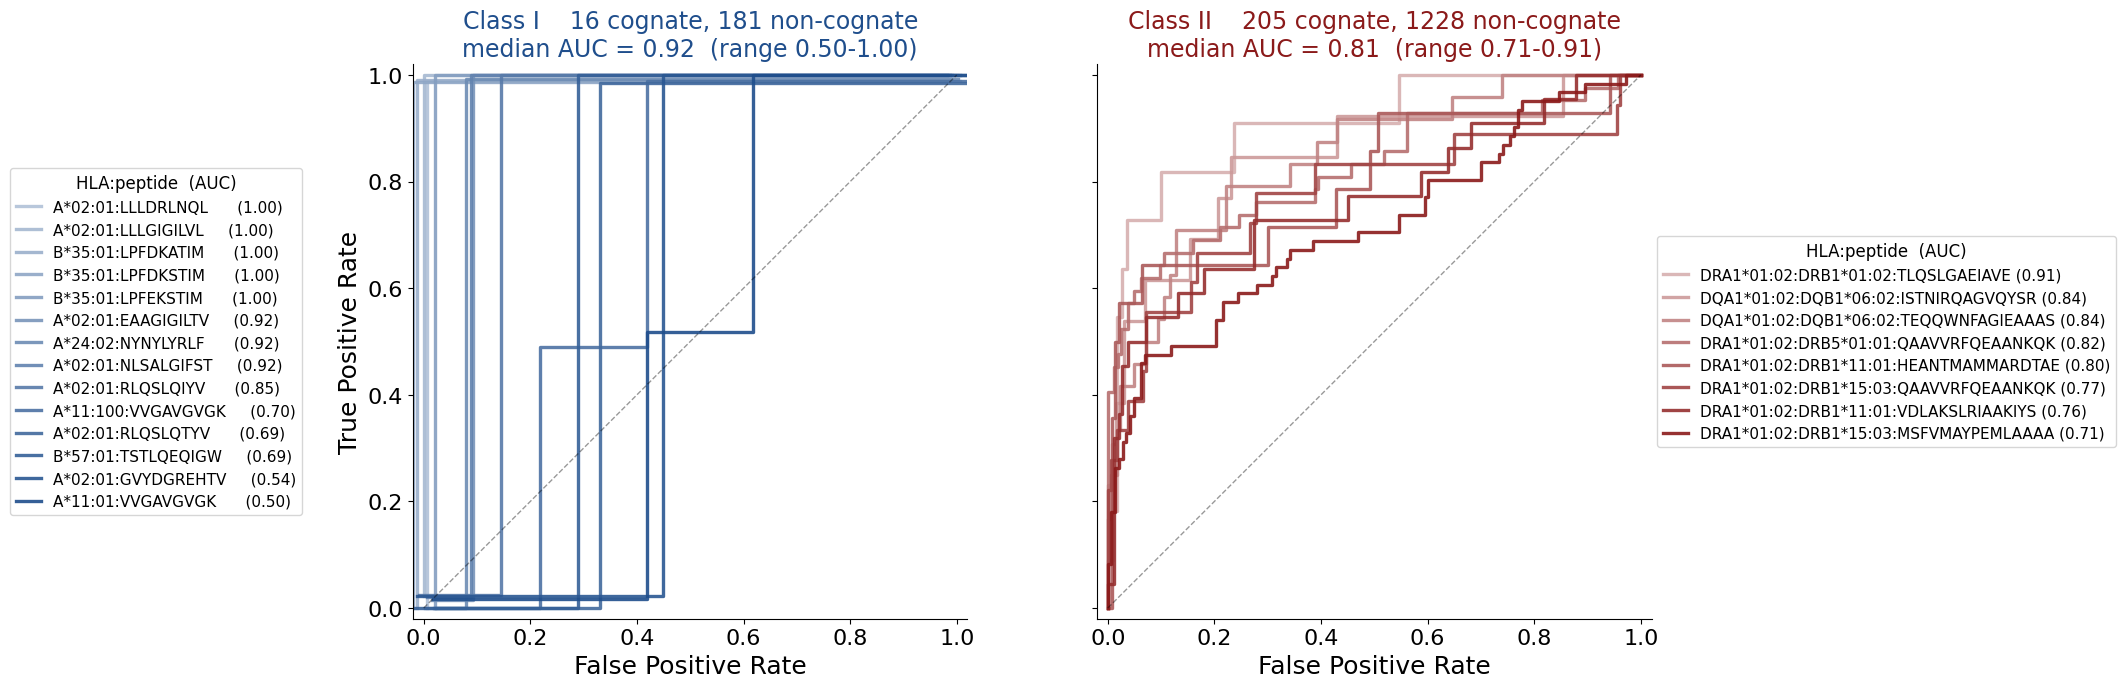

In [3]:
import matplotlib.colors as mcolors

def make_palette(base_hex, n, start=0.35, end=1.0):
    base = np.array(mcolors.to_rgb(base_hex))
    return [tuple((1 - t) * np.array([1.0, 1.0, 1.0]) + t * base)
            for t in np.linspace(start, end, n)]

def jitter_step(fpr, tpr, x_amp=0.025, y_amp=0.025, seed=None):
    rng = np.random.default_rng(seed)
    return fpr + rng.uniform(-x_amp, x_amp), np.clip(tpr + rng.uniform(-y_amp, y_amp), 0, 1.0)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(17, 7.2),
                                gridspec_kw=dict(wspace=0.08))

# Panel a - class I (blue family), jittered step ROCs, sorted by AUC
palette_I = make_palette('#1f4e8c', len(roc_I))
for i, r in enumerate(roc_I):
    fx, tx = jitter_step(r['fpr'], r['tpr'], seed=i)
    axA.plot(fx, tx, color=palette_I[i], lw=2.4, alpha=0.9,
             label=f"{r['antigen']:<22s} ({r['auc']:.2f})")
axA.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1.0)
axA.set_xlim(-0.02, 1.02); axA.set_ylim(-0.02, 1.02); axA.set_box_aspect(1)
axA.set_xlabel('False Positive Rate', fontsize=18)
axA.set_ylabel('True Positive Rate', fontsize=18)
axA.tick_params(labelsize=16)
axA.set_title(f"Class I    16 cognate, 181 non-cognate\n"
              f"median AUC = {med_I:.2f}  (range {min(r['auc'] for r in roc_I):.2f}-{max(r['auc'] for r in roc_I):.2f})",
              fontsize=17, color='#1f4e8c', loc='center')
axA.legend(loc='center right', bbox_to_anchor=(-0.20, 0.5), fontsize=11,
           frameon=True, title='HLA:peptide  (AUC)', title_fontsize=12,
           handlelength=1.6, borderaxespad=0)
axA.spines[['top', 'right']].set_visible(False)

# Panel b - class II (red family), smooth ROCs, sorted by AUC
palette_II = make_palette('#8b1a1a', len(roc_II))
for i, r in enumerate(roc_II):
    axB.plot(r['fpr'], r['tpr'], color=palette_II[i], lw=2.4, alpha=0.9,
             label=f"{r['antigen']:<22s} ({r['auc']:.2f})")
axB.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1.0)
axB.set_xlim(-0.02, 1.02); axB.set_ylim(-0.02, 1.02); axB.set_box_aspect(1)
axB.set_xlabel('False Positive Rate', fontsize=18)
axB.set_ylabel('')
axB.tick_params(labelleft=False)
axB.tick_params(labelsize=16)
axB.set_title(f"Class II    205 cognate, 1228 non-cognate\n"
              f"median AUC = {med_II:.2f}  (range {min(r['auc'] for r in roc_II):.2f}-{max(r['auc'] for r in roc_II):.2f})",
              fontsize=17, color='#8b1a1a', loc='center')
axB.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=11,
           frameon=True, title='HLA:peptide  (AUC)', title_fontsize=12,
           handlelength=1.6, borderaxespad=0)
axB.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.savefig('Fig4_ab_validation_ROCs.png', dpi=300, bbox_inches='tight')
print('Saved: Fig4_ab_validation_ROCs.png')
plt.show()

## Save AUC summary CSV (for downstream use by panel c)

In [4]:
auc_df = pd.DataFrame([
    {'mhc_class': 'I',  'antigen': r['antigen'], 'auc_af3': r['auc'],
     'n_cognate': r['n_cognate'], 'n_noncognate': r['n_noncognate']}
    for r in roc_I
] + [
    {'mhc_class': 'II', 'antigen': r['antigen'], 'auc_af3': r['auc'],
     'n_cognate': r['n_cognate'], 'n_noncognate': r['n_noncognate']}
    for r in roc_II
])
auc_df.to_csv('per_antigen_auc_AF3.csv', index=False)
print(f'Wrote per_antigen_auc_AF3.csv ({len(auc_df)} rows)')
print(auc_df.to_string(index=False))

Wrote per_antigen_auc_AF3.csv (22 rows)
mhc_class                               antigen  auc_af3  n_cognate  n_noncognate
        I                     A*02:01:LLLDRLNQL 1.000000          1            13
        I                    A*02:01:LLLGIGILVL 1.000000          1            12
        I                     B*35:01:LPFDKATIM 1.000000          1            12
        I                     B*35:01:LPFDKSTIM 1.000000          1            12
        I                     B*35:01:LPFEKSTIM 1.000000          1            12
        I                    A*02:01:EAAGIGILTV 0.923077          1            13
        I                     A*24:02:NYNYLYRLF 0.923077          1            13
        I                    A*02:01:NLSALGIFST 0.916667          1            12
        I                     A*02:01:RLQSLQIYV 0.846154          1            13
        I                    A*11:100:VVGAVGVGK 0.700000          2            10
        I                     A*02:01:RLQSLQTYV 0.692308  